# Enhanced Clustering Tutorial: Unveiling Patterns in Data

Welcome to this comprehensive tutorial on clustering, a fundamental technique in unsupervised machine learning. This notebook is designed to be a clear, simple, and detailed resource for understanding and applying various clustering algorithms. Whether you're a student, an educator, or a data enthusiast, this guide will walk you through the concepts, implementations, and best practices of clustering.

## 1. Introduction to Unsupervised Learning and Clustering

### What is Unsupervised Learning?

**Unsupervised learning** is a branch of machine learning that deals with finding patterns in data without explicit guidance or labeled examples. Unlike supervised learning, where models learn from input-output pairs, unsupervised learning algorithms work with unlabeled data to discover hidden structures, relationships, or groupings within the dataset. The primary goal is to infer the underlying distribution of the data or to group similar data points together.

### What is Clustering?

**Clustering** is a specific task within unsupervised learning that involves partitioning a dataset into subsets (clusters) such that data points within the same cluster are more similar to each other than to those in other clusters. Imagine having a collection of diverse items and wanting to organize them into meaningful groups without any predefined categories. Clustering algorithms help achieve this by identifying inherent groupings based on the characteristics of the data.

#### Goals of Clustering:

The main objectives of clustering can be summarized as follows:

*   **High Intra-Cluster Similarity**: Data points belonging to the same cluster should be as similar as possible to each other. This means they share common characteristics or properties.
*   **Low Inter-Cluster Similarity**: Data points in different clusters should be as dissimilar as possible. This ensures that the identified groups are distinct and meaningful.

#### Real-World Applications of Clustering:

Clustering is a versatile technique with numerous applications across various domains:

*   **Customer Segmentation**: Grouping customers based on their purchasing behavior, demographics, or interests to tailor marketing strategies.
*   **Image Segmentation**: Dividing an image into regions of similar pixels for object recognition or analysis.
*   **Document Analysis**: Organizing large collections of documents into topics or themes.
*   **Anomaly Detection**: Identifying unusual patterns or outliers in data, such as fraudulent transactions or network intrusions.
*   **Genomic Analysis**: Grouping genes with similar expression patterns to understand biological processes.
*   **City Planning**: Identifying areas with similar characteristics for urban development or resource allocation.

In the following sections, we will delve into one of the most popular and foundational clustering algorithms: K-Means.

## 2. K-Means Clustering: A Step-by-Step Approach

K-Means is an iterative algorithm that aims to partition `n` observations into `k` clusters, where each observation belongs to the cluster with the nearest mean (centroid). The algorithm works as follows:

### The K-Means Algorithm Steps:

1.  **Initialization**: Choose the number of clusters, `k`, and randomly initialize `k` centroids (cluster centers) in the data space.
2.  **Assignment Step (E-step - Expectation)**: Assign each data point to the nearest centroid. The 'distance' is typically Euclidean distance.
3.  **Update Step (M-step - Maximization)**: Recalculate the centroids by taking the mean of all data points assigned to each cluster.
4.  **Iteration**: Repeat steps 2 and 3 until the centroids no longer change significantly (convergence) or a maximum number of iterations is reached.

Let's illustrate this process with a practical example.

### 2.1 Data Generation and Visualization

First, we'll generate a synthetic dataset using `make_blobs` from `sklearn.datasets`. This function is excellent for creating isotropic Gaussian blobs for clustering.

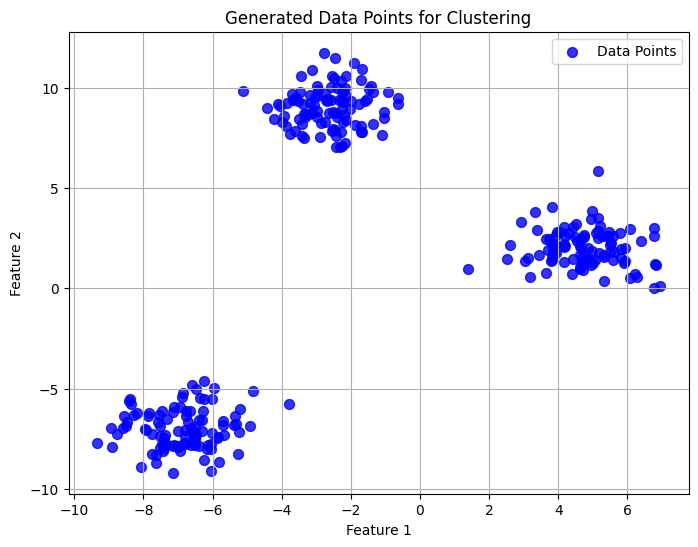

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Generate synthetic data
n_samples = 300  # Number of samples
n_features = 2   # Number of features (for 2D visualization)
n_centers = 3    # True number of centers for data generation
random_state = 42 # for reproducibility

X, y_true = make_blobs(n_samples=n_samples, centers=n_centers, n_features=n_features, random_state=random_state)

# Visualize the generated data
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c='blue', s=50, alpha=0.8, label='Data Points')
plt.title('Generated Data Points for Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

### 2.2 Initializing Centroids

The first step in the K-Means algorithm is to choose the number of clusters, `k`, and initialize `k` centroids. A common approach is to randomly select `k` data points from the dataset to serve as initial centroids.

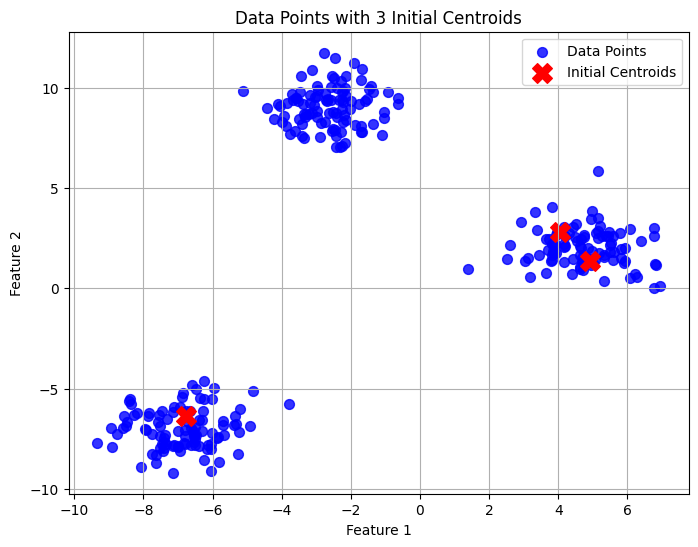

In [2]:
# Define the number of clusters (k)
k = 3

# Set random seed for reproducibility
np.random.seed(42)

# Randomly select k data points as initial centroids
initial_centroid_indices = np.random.choice(len(X), k, replace=False)
centroids = X[initial_centroid_indices]

# Visualize initial centroids along with data points
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c='blue', s=50, alpha=0.8, label='Data Points')
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, label='Initial Centroids')
plt.title(f'Data Points with {k} Initial Centroids')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

### 2.3 The Iterative Process: Assignment and Update

The core of the K-Means algorithm lies in its iterative nature, alternating between two steps: the **Assignment Step** (E-step) and the **Update Step** (M-step).

In [3]:
def compute_distances(X, centroids):
    """
    Calculates the Euclidean distance between each data point and each centroid.
    """
    return np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)

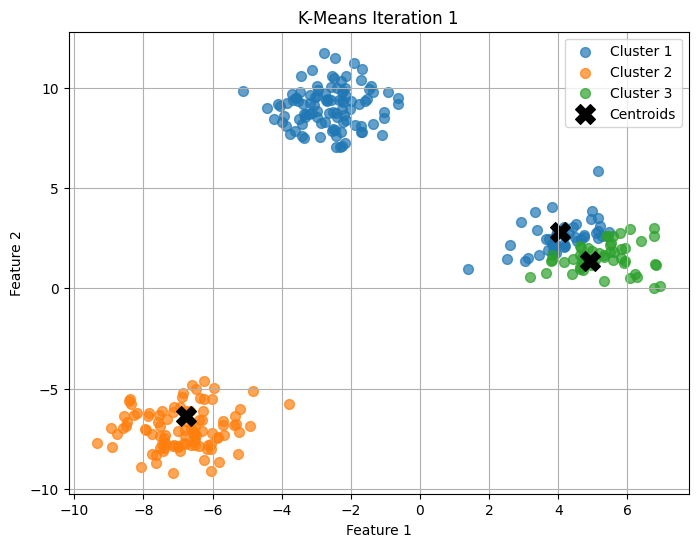

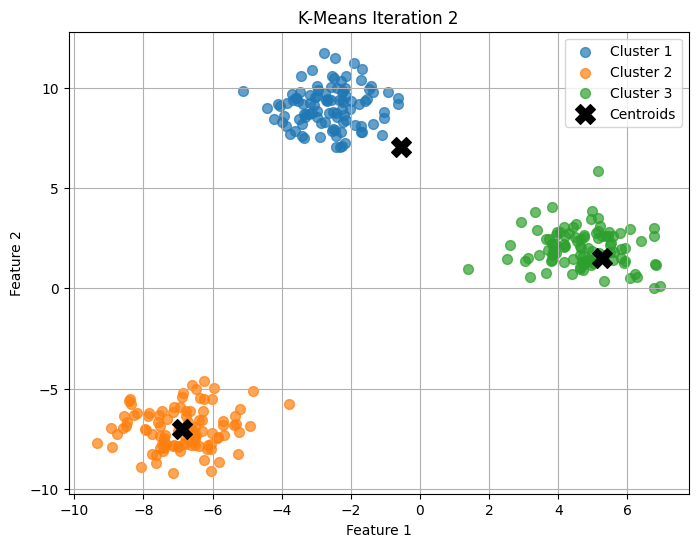

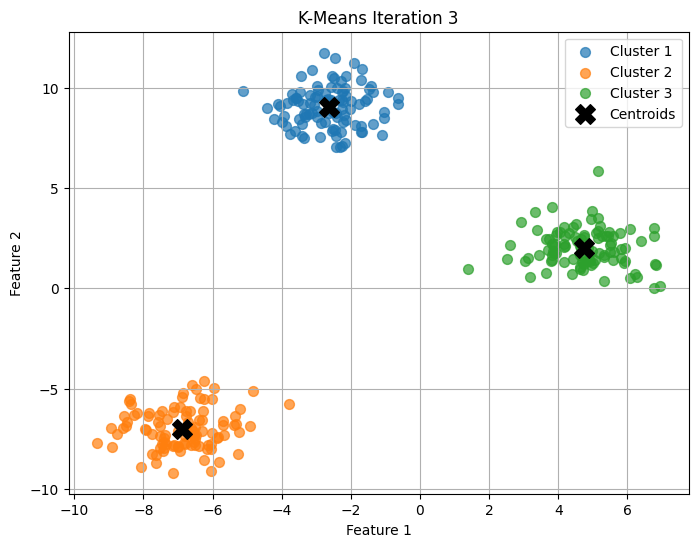


Converged at iteration 3!


In [4]:
# Store history for visualization
centroids_history = [centroids.copy()]
cluster_labels_history = []

max_iterations = 10

for iteration in range(max_iterations):
    # 1. Assignment Step
    distances = compute_distances(X, centroids)
    cluster_labels = np.argmin(distances, axis=1)
    cluster_labels_history.append(cluster_labels.copy())

    # 2. Update Step
    new_centroids = np.array([X[cluster_labels == i].mean(axis=0) if np.any(cluster_labels == i) else centroids[i] for i in range(k)])

    # 3. Visualize current iteration
    plt.figure(figsize=(8, 6))
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
    for i in range(k):
        plt.scatter(X[cluster_labels == i][:, 0], X[cluster_labels == i][:, 1], s=50, alpha=0.7, c=colors[i], label=f'Cluster {i+1}')
    plt.scatter(centroids[:, 0], centroids[:, 1], c='black', marker='X', s=200, label='Centroids')
    plt.title(f'K-Means Iteration {iteration + 1}')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()
    plt.grid(True)
    plt.show()

    # 4. Check for convergence
    if np.allclose(centroids, new_centroids):
        print(f'\nConverged at iteration {iteration + 1}!')
        break

    centroids = new_centroids
    centroids_history.append(centroids.copy())

## 3. Finding the Optimal Number of Clusters (k)

Two common methods to determine the best `k` are the **Elbow Method** and the **Silhouette Score**.

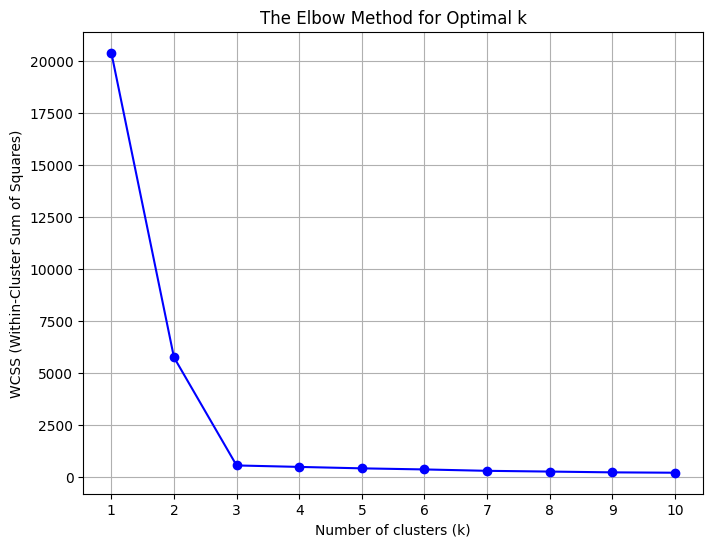

In [5]:
from sklearn.cluster import KMeans

wcss = []
k_range = range(1, 11)

for i in k_range:
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(k_range, wcss, marker='o', linestyle='-', color='b')
plt.title('The Elbow Method for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

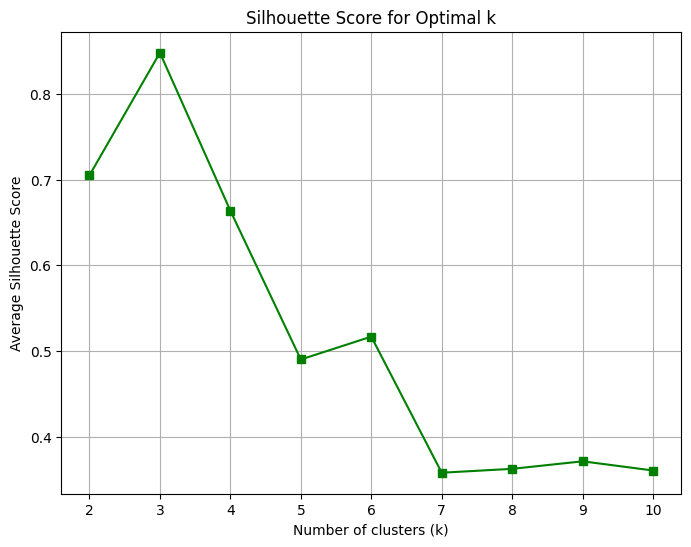

In [6]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
k_range_sil = range(2, 11)

for i in k_range_sil:
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    cluster_labels = kmeans.fit_predict(X)
    silhouette_avg = silhouette_score(X, cluster_labels)
    silhouette_scores.append(silhouette_avg)

plt.figure(figsize=(8, 6))
plt.plot(k_range_sil, silhouette_scores, marker='s', linestyle='-', color='g')
plt.title('Silhouette Score for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Average Silhouette Score')
plt.xticks(k_range_sil)
plt.grid(True)
plt.show()

## 4. Scikit-Learn Implementation

In practice, we use optimized libraries like `scikit-learn`.

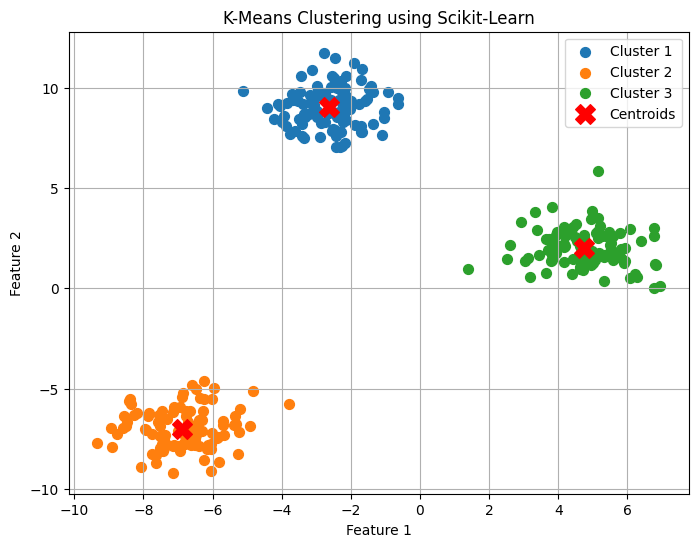

In [7]:
kmeans_sklearn = KMeans(n_clusters=3, init='k-means++', max_iter=300, n_init=10, random_state=42)
y_kmeans = kmeans_sklearn.fit_predict(X)
sklearn_centroids = kmeans_sklearn.cluster_centers_

plt.figure(figsize=(8, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for i in range(3):
    plt.scatter(X[y_kmeans == i, 0], X[y_kmeans == i, 1], s=50, c=colors[i], label=f'Cluster {i+1}')
plt.scatter(sklearn_centroids[:, 0], sklearn_centroids[:, 1], s=200, c='red', marker='X', label='Centroids')
plt.title('K-Means Clustering using Scikit-Learn')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

## 5. Brief Overview of Other Clustering Algorithms

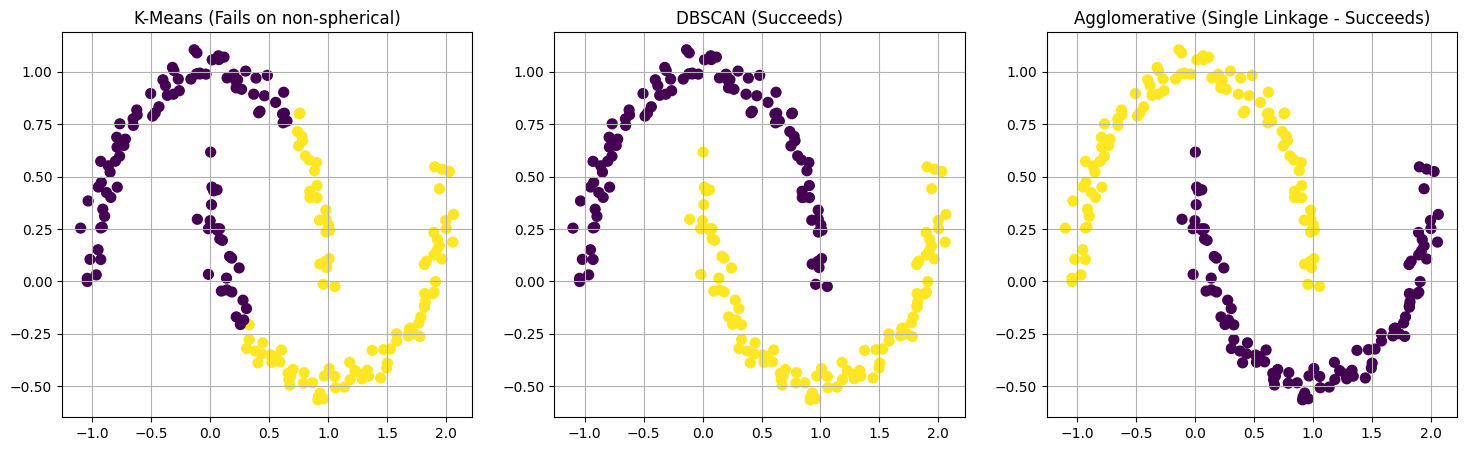

In [8]:
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN, AgglomerativeClustering

X_moons, _ = make_moons(n_samples=200, noise=0.05, random_state=42)

kmeans_moons = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_kmeans = kmeans_moons.fit_predict(X_moons)

dbscan = DBSCAN(eps=0.2, min_samples=5)
labels_dbscan = dbscan.fit_predict(X_moons)

agglo = AgglomerativeClustering(n_clusters=2, linkage='single')
labels_agglo = agglo.fit_predict(X_moons)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].scatter(X_moons[:, 0], X_moons[:, 1], c=labels_kmeans, cmap='viridis', s=50)
axes[0].set_title('K-Means (Fails on non-spherical)')
axes[1].scatter(X_moons[:, 0], X_moons[:, 1], c=labels_dbscan, cmap='viridis', s=50)
axes[1].set_title('DBSCAN (Succeeds)')
axes[2].scatter(X_moons[:, 0], X_moons[:, 1], c=labels_agglo, cmap='viridis', s=50)
axes[2].set_title('Agglomerative (Single Linkage - Succeeds)')
for ax in axes: ax.grid(True)
plt.show()

## 6. Summary and Best Practices

*   **Scaling is Crucial**: Distance-based algorithms like K-Means and DBSCAN are highly sensitive to the scale of the features. Always scale your data (e.g., using `StandardScaler`) before applying these algorithms.
*   **Algorithm Selection**:
    *   Use **K-Means** for general-purpose, fast clustering when you expect roughly spherical clusters and know the approximate number of clusters.
    *   Use **DBSCAN** when you have noise/outliers and expect clusters of arbitrary shapes.
    *   Use **Hierarchical Clustering** when you want a hierarchy of clusters (dendrogram) and don't want to specify `k` upfront.
*   **Evaluation**: Use the Elbow Method and Silhouette Score to guide your choice of hyperparameters, but always visually inspect the results if possible and ensure the clusters make sense in the context of your domain.